<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca domowa: LAB10_CNN

# Autor: Łukasz Wysocki

Celem pracy jest sprawdzenie, jak LeNet-5 zachowuje się przy optymalizacji wejścia oraz przy celowanych atakach adversarialnych na MNIST.

Rozwiązuję dwa zadania:

1. Generuję obrazy klasyfikowane przez CNN jako cyfry $0,
\ldots,9$.
2. Dla prawdziwych cyfr MNIST uczę perturbacje, które zmieniają decyzję modelu na zadaną błędną klasę.

Wagi sieci są zamrożone w obu eksperymentach optymalizacyjnych.

In [1]:
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import torch.nn as nn
import torch.nn.functional as F

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

mnist_mean = 0.1307
mnist_std = 0.3081
pixel_min = (0.0 - mnist_mean) / mnist_std
pixel_max = (1.0 - mnist_mean) / mnist_std

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_std,))
])

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=2048,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=256,
    shuffle=False
)

Working on cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.35MB/s]


In [3]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.dropout = nn.Dropout(0.05)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [4]:
model = LeNet5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 5
training_rows = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in trainloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in testloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    training_rows.append({
        "epoch": epoch + 1,
        "training_loss": running_loss / len(trainloader),
        "test_accuracy": correct / total
    })

training_summary = pd.DataFrame(training_rows)
training_summary

,epoch,training_loss,test_accuracy
0,1,1.455133,0.8286
1,2,0.516970,0.8986
2,3,0.322763,0.9239
3,4,0.243048,0.9412
4,5,0.188240,0.9558


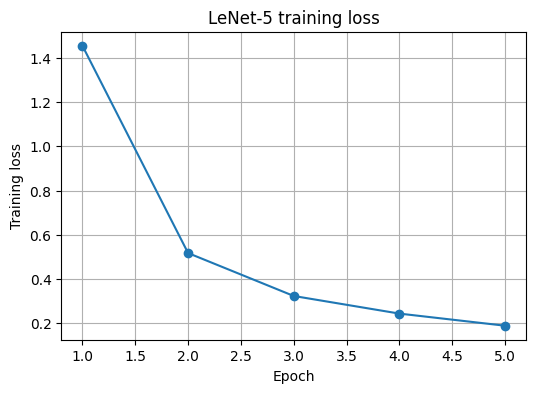

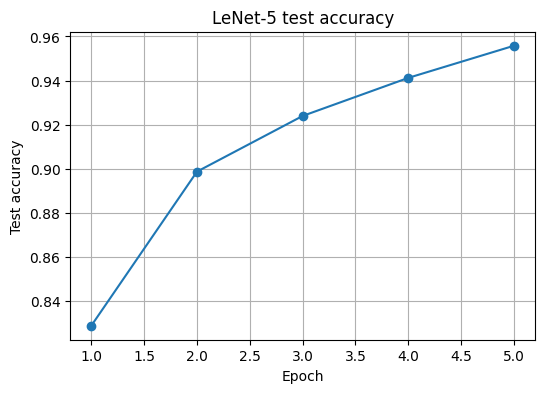

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(training_summary["epoch"], training_summary["training_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("LeNet-5 training loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(training_summary["epoch"], training_summary["test_accuracy"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("LeNet-5 test accuracy")
plt.grid(True)
plt.show()

Model został wytrenowany poprawnie. W ostatniej epoce `training_loss = 0.188240`, a `test_accuracy = 0.9558`.

To jest wystarczający wynik do dalszych eksperymentów: model dobrze rozpoznaje MNIST i ma sensowne gradienty do optymalizacji wejścia.

## Task 1 — CNN Dreams

Optymalizuję bezpośrednio obraz wejściowy. Startuję od losowego szumu i zmieniam piksele tak, aby zamrożony LeNet-5 klasyfikował obraz jako wybraną cyfrę.

Funkcja celu:

$$
Loss(x,y)=CE(f(x),y)+\lambda_{l2}\cdot mean(x^2).
$$

Testuję wartości $\lambda_{l2}\in\{0,0.01,0.1,1,10\}$.

In [6]:
def denormalize(x):
    return x * mnist_std + mnist_mean


def show_image_grid(images, titles=None, rows=1, cols=10, figsize=(14, 2.2)):
    images = images.detach().cpu()
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if rows == 1:
        axes = np.array([axes])

    for i, ax in enumerate(axes.ravel()):
        if i < len(images):
            img = denormalize(images[i]).squeeze().clamp(0, 1)
            ax.imshow(img, cmap="gray")
            if titles is not None:
                ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def get_probs(x):
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
    return probs

In [7]:
def optimize_cnn_dreams(lambda_l2=0.0, steps=400, lr=0.08):
    model.eval()

    x = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
    targets = torch.arange(10, device=device)
    optimizer = torch.optim.Adam([x], lr=lr)

    confidence_history = []
    loss_history = []
    frames = []

    for step in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        ce_loss = F.cross_entropy(logits, targets)
        l2_loss = x.pow(2).mean()
        loss = ce_loss + lambda_l2 * l2_loss
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            x.clamp_(pixel_min, pixel_max)
            probs = torch.softmax(model(x), dim=1)
            target_confidences = probs[torch.arange(10, device=device), targets]
            confidence_history.append(target_confidences.detach().cpu().numpy())
            loss_history.append(loss.item())

            if step % 20 == 0 or step == steps - 1:
                frames.append(x.detach().cpu().clone())

    return x.detach(), np.array(confidence_history), np.array(loss_history), frames

In [8]:
dream_lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
dream_results = {}
dream_rows = []

for lambda_l2 in dream_lambdas:
    images, confidence_history, loss_history, frames = optimize_cnn_dreams(
        lambda_l2=lambda_l2,
        steps=400,
        lr=0.08
    )

    probs = get_probs(images)
    target_probs = probs[torch.arange(10), torch.arange(10)].detach().cpu().numpy()
    predictions = probs.argmax(dim=1).detach().cpu().numpy()
    image_l2 = images.view(images.size(0), -1).pow(2).mean(dim=1).mean().item()

    dream_results[lambda_l2] = {
        "images": images,
        "confidence_history": confidence_history,
        "loss_history": loss_history,
        "frames": frames,
        "predictions": predictions,
        "target_probs": target_probs,
        "image_l2": image_l2
    }

    dream_rows.append({
        "lambda_l2": lambda_l2,
        "correct_targets": int((predictions == np.arange(10)).sum()),
        "mean_final_confidence": float(target_probs.mean()),
        "min_final_confidence": float(target_probs.min()),
        "mean_input_squared_value": image_l2
    })

dream_summary = pd.DataFrame(dream_rows)
dream_summary

,lambda_l2,correct_targets,mean_final_confidence,min_final_confidence,mean_input_squared_value
0,0.00,10,0.996993,0.995968,0.630739
1,0.01,10,0.996677,0.994739,0.437690
2,0.10,10,0.996732,0.995655,0.074656
3,1.00,10,0.993763,0.992095,0.007353
4,10.00,10,0.982449,0.977436,0.003892


lambda_l2 = 0.0


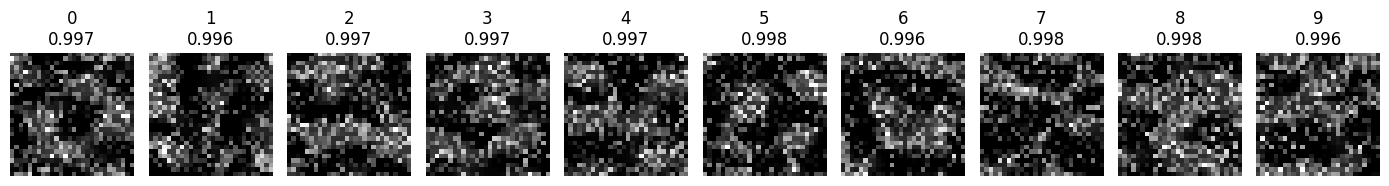

lambda_l2 = 0.01


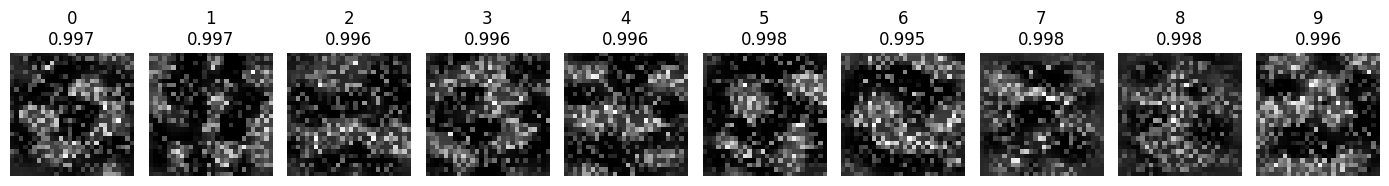

lambda_l2 = 0.1


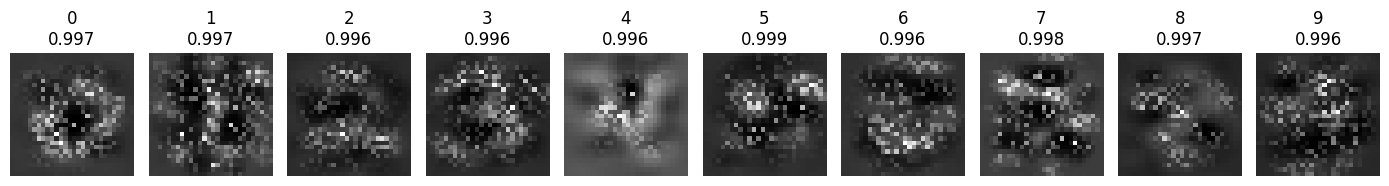

lambda_l2 = 1.0


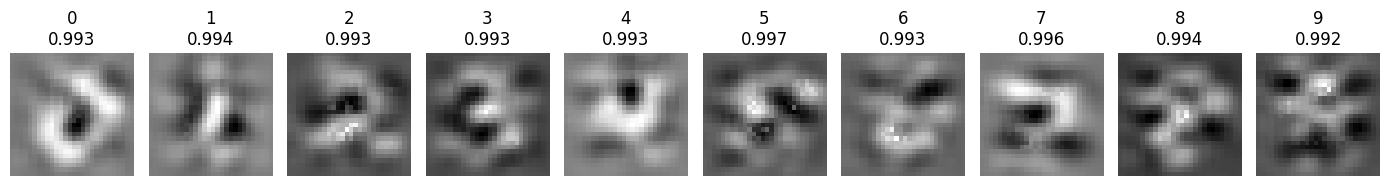

lambda_l2 = 10.0


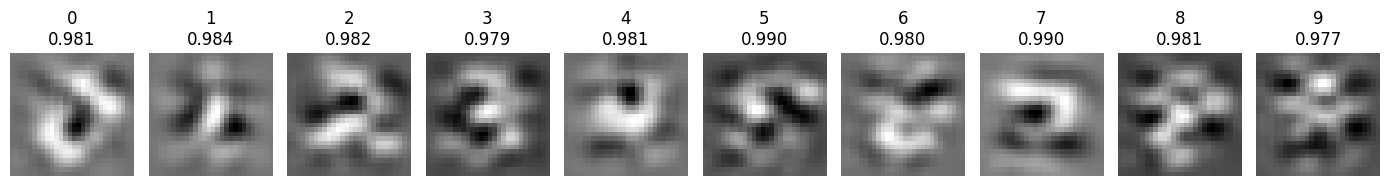

In [9]:
for lambda_l2 in dream_lambdas:
    images = dream_results[lambda_l2]["images"]
    target_probs = dream_results[lambda_l2]["target_probs"]
    titles = [f"{i}\n{target_probs[i]:.3f}" for i in range(10)]
    print(f"lambda_l2 = {lambda_l2}")
    show_image_grid(images, titles=titles)

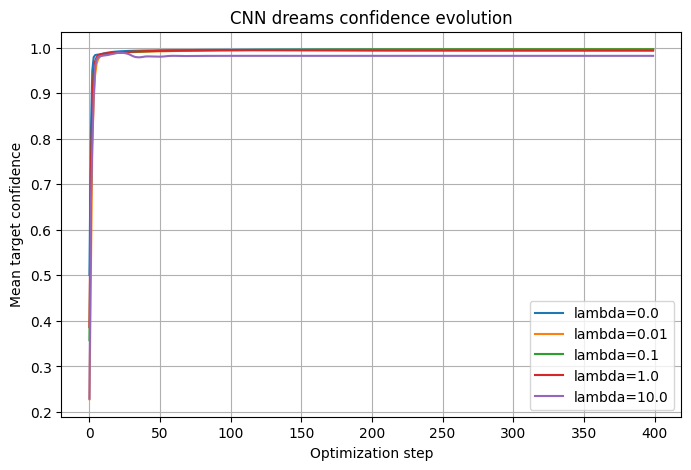

In [10]:
plt.figure(figsize=(8, 5))

for lambda_l2 in dream_lambdas:
    mean_confidence = dream_results[lambda_l2]["confidence_history"].mean(axis=1)
    plt.plot(mean_confidence, label=f"lambda={lambda_l2}")

plt.xlabel("Optimization step")
plt.ylabel("Mean target confidence")
plt.title("CNN dreams confidence evolution")
plt.legend()
plt.grid(True)
plt.show()

### Task 1 — odpowiedzi

Wartości liczbowe są w tabeli `dream_summary`. Dla wszystkich testowanych wartości $\lambda_{l2}$ model uzyskał `correct_targets = 10/10`.

Średnia końcowa pewność klasy docelowej wyniosła: `0.996993` dla $\lambda_{l2}=0$, `0.996677` dla `0.01`, `0.996732` dla `0.1`, `0.993763` dla `1.0` i `0.982449` dla `10.0`.

Kara L2 mocno zmniejszyła średnią wartość $x^2$: z `0.630739` dla $\lambda_{l2}=0$ do `0.003892` dla $\lambda_{l2}=10$. Obrazy są wtedy mniej chaotyczne, ale nadal nie są naturalnymi cyframi MNIST.

W porównaniu z MLP z homework09 obrazy CNN są bardziej lokalnie uporządkowane: częściej widać fragmenty łuków, kresek i krawędzi. Wynika to z biasu przestrzennego CNN: konwolucje szukają lokalnych wzorców, a MLP traktuje piksele bardziej niezależnie.

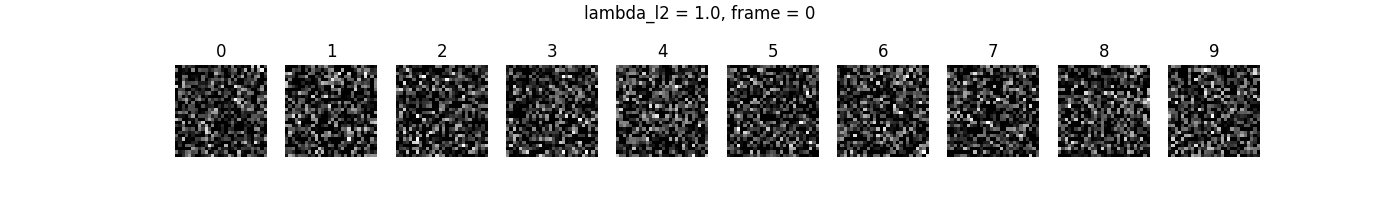

In [11]:
def make_dream_animation(lambda_l2=1.0, filename="cnn_dream_lambda_1.gif"):
    frames = dream_results[lambda_l2]["frames"]
    fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))

    def update(frame_idx):
        images = frames[frame_idx]
        for i, ax in enumerate(axes):
            img = denormalize(images[i]).squeeze().clamp(0, 1)
            ax.clear()
            ax.imshow(img, cmap="gray")
            ax.set_title(str(i))
            ax.axis("off")
        fig.suptitle(f"lambda_l2 = {lambda_l2}, frame = {frame_idx}")

    anim = FuncAnimation(fig, update, frames=len(frames), interval=150)
    anim.save(filename, writer=PillowWriter(fps=8))
    plt.close(fig)
    display(Image(filename=filename))

make_dream_animation(lambda_l2=1.0, filename="cnn_dream_lambda_1.gif")

## Task 2 — Adversarial Examples

Dla prawdziwych cyfr MNIST uczę perturbację $\delta$. Wagi LeNet-5 są zamrożone.

Obraz adversarialny:

$$
x_{adv}=x+\delta.
$$

Funkcja celu:

$$
Loss(\delta)=CE(f(x+\delta),y_{wrong})+\lambda_{l2}\cdot mean(\delta^2).
$$

Biorę 9 poprawnie klasyfikowanych przykładów dla każdej cyfry. Dla każdej klasy docelowe błędne etykiety to dokładnie wszystkie pozostałe cyfry.

In [12]:
def collect_correct_examples_by_class(n_per_class=9):
    model.eval()
    selected = {label: [] for label in range(10)}

    with torch.no_grad():
        for x_batch, y_batch in testloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            preds = logits.argmax(dim=1)

            for i in range(x_batch.size(0)):
                label = int(y_batch[i].item())
                if preds[i].item() == label and len(selected[label]) < n_per_class:
                    selected[label].append(x_batch[i].detach().cpu())

            if all(len(selected[label]) == n_per_class for label in range(10)):
                break

    images = []
    true_labels = []
    target_labels = []

    for true_label in range(10):
        wrong_targets = [label for label in range(10) if label != true_label]
        for image, target_label in zip(selected[true_label], wrong_targets):
            images.append(image)
            true_labels.append(true_label)
            target_labels.append(target_label)

    images = torch.stack(images).to(device)
    true_labels = torch.tensor(true_labels, device=device)
    target_labels = torch.tensor(target_labels, device=device)

    return images, true_labels, target_labels

real_images, real_labels, wrong_labels = collect_correct_examples_by_class(n_per_class=9)

attack_plan = pd.crosstab(
    pd.Series(real_labels.detach().cpu().numpy(), name="true_label"),
    pd.Series(wrong_labels.detach().cpu().numpy(), name="target_wrong_label")
)

print(real_images.shape)
attack_plan

torch.Size([90, 1, 28, 28])


target_wrong_label,0,1,2,3,4,5,6,7,8,9
true_label,,,,,,,,,,
0,0,1,1,1,1,1,1,1,1,1
1,1,0,1,1,1,1,1,1,1,1
2,1,1,0,1,1,1,1,1,1,1
3,1,1,1,0,1,1,1,1,1,1
4,1,1,1,1,0,1,1,1,1,1
5,1,1,1,1,1,0,1,1,1,1
6,1,1,1,1,1,1,0,1,1,1
7,1,1,1,1,1,1,1,0,1,1
8,1,1,1,1,1,1,1,1,0,1


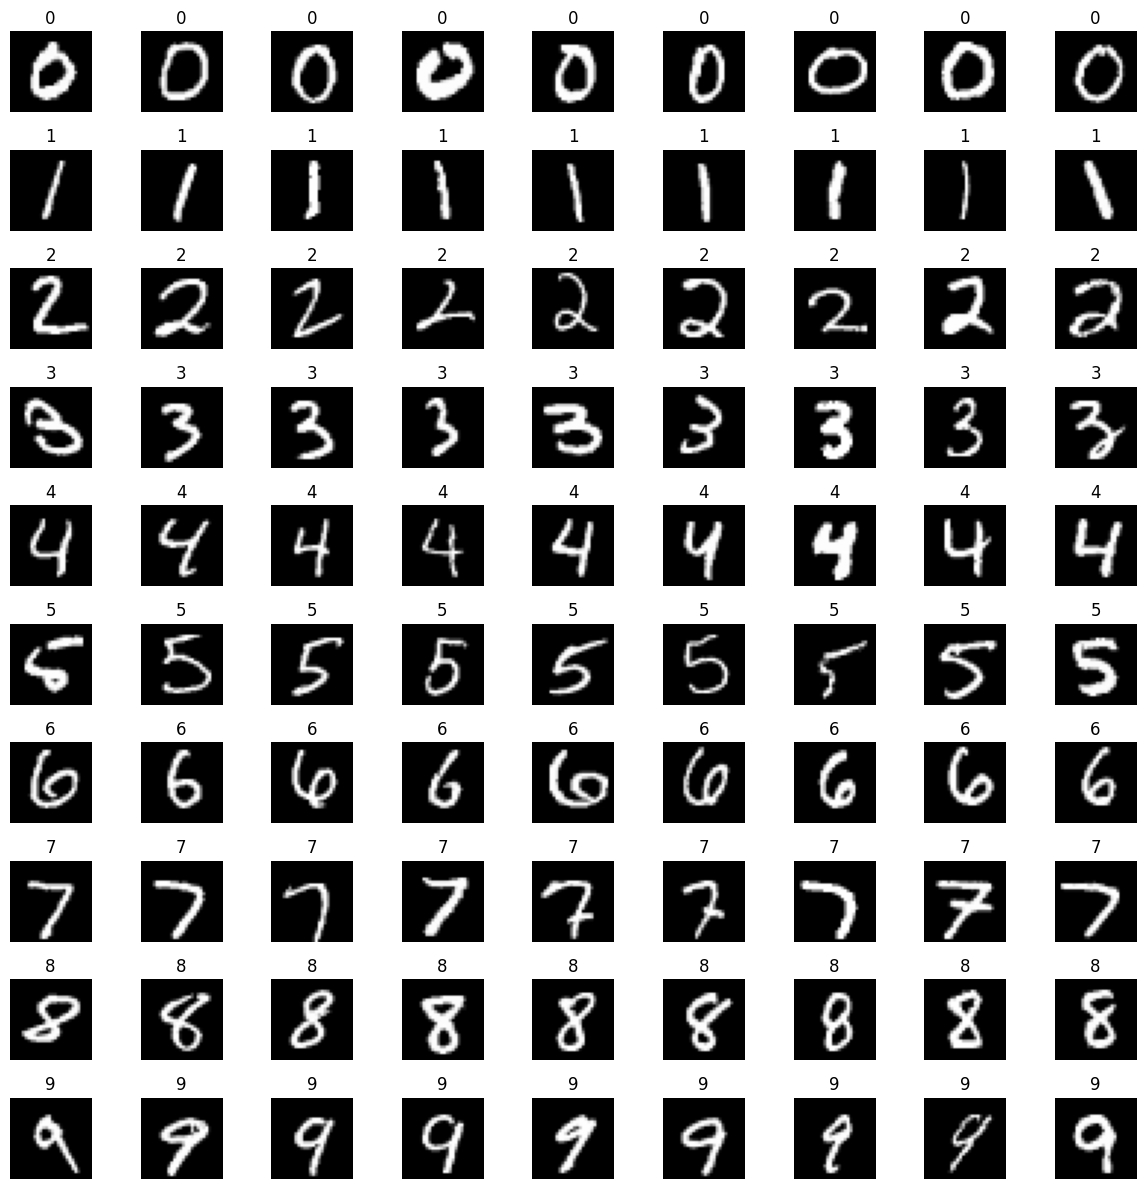

In [13]:
show_image_grid(
    real_images,
    titles=[str(label.item()) for label in real_labels],
    rows=10,
    cols=9,
    figsize=(12, 12)
)

In [14]:
def create_adversarial_examples(images, true_labels, target_labels, lambda_l2=0.1, steps=300, lr=0.05):
    model.eval()

    images = images.detach()
    delta = torch.zeros_like(images, requires_grad=True)
    optimizer = torch.optim.Adam([delta], lr=lr)

    loss_history = []
    target_confidence_history = []
    true_confidence_history = []

    for step in range(steps):
        optimizer.zero_grad()
        adv_images = (images + delta).clamp(pixel_min, pixel_max)
        logits = model(adv_images)
        ce_loss = F.cross_entropy(logits, target_labels)
        l2_loss = delta.pow(2).mean()
        loss = ce_loss + lambda_l2 * l2_loss
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            adv_images = (images + delta).clamp(pixel_min, pixel_max)
            probs = torch.softmax(model(adv_images), dim=1)
            target_conf = probs[torch.arange(images.size(0), device=device), target_labels]
            true_conf = probs[torch.arange(images.size(0), device=device), true_labels]
            loss_history.append(loss.item())
            target_confidence_history.append(target_conf.detach().cpu().numpy())
            true_confidence_history.append(true_conf.detach().cpu().numpy())

    adv_images = (images + delta).clamp(pixel_min, pixel_max).detach()
    delta = (adv_images - images).detach()

    return adv_images, delta, np.array(loss_history), np.array(target_confidence_history), np.array(true_confidence_history)

In [15]:
adv_lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
adv_results = {}
adv_rows = []

for lambda_l2 in adv_lambdas:
    adv_images, delta, loss_history, target_conf_history, true_conf_history = create_adversarial_examples(
        images=real_images,
        true_labels=real_labels,
        target_labels=wrong_labels,
        lambda_l2=lambda_l2,
        steps=300,
        lr=0.05
    )

    with torch.no_grad():
        probs = torch.softmax(model(adv_images), dim=1)
        preds = probs.argmax(dim=1)
        target_probs = probs[torch.arange(adv_images.size(0), device=device), wrong_labels]
        true_probs = probs[torch.arange(adv_images.size(0), device=device), real_labels]
        success = (preds == wrong_labels).float().mean().item()
        mean_delta_l2 = delta.view(delta.size(0), -1).norm(p=2, dim=1).mean().item()
        max_abs_delta = delta.abs().amax(dim=(1, 2, 3)).mean().item()

    adv_results[lambda_l2] = {
        "adv_images": adv_images,
        "delta": delta,
        "loss_history": loss_history,
        "target_conf_history": target_conf_history,
        "true_conf_history": true_conf_history,
        "preds": preds.detach(),
        "target_probs": target_probs.detach(),
        "true_probs": true_probs.detach(),
        "success": success,
        "mean_delta_l2": mean_delta_l2,
        "max_abs_delta": max_abs_delta
    }

    adv_rows.append({
        "lambda_l2": lambda_l2,
        "success_rate": success,
        "mean_delta_l2": mean_delta_l2,
        "mean_max_abs_delta": max_abs_delta,
        "mean_target_confidence": target_probs.mean().item(),
        "mean_true_confidence": true_probs.mean().item()
    })

adv_summary = pd.DataFrame(adv_rows)
adv_summary

,lambda_l2,success_rate,mean_delta_l2,mean_max_abs_delta,mean_target_confidence,mean_true_confidence
0,0.00,0.688889,20.707508,3.184418,0.596201,0.192276
1,0.01,0.744444,21.169277,3.183366,0.630752,0.167522
2,0.10,0.900000,21.400133,3.127805,0.819557,0.103234
3,1.00,0.900000,17.390020,3.110479,0.804612,0.109316
4,10.00,0.633333,12.258387,2.919809,0.418622,0.358435


In [16]:
successful_lambdas = adv_summary.loc[adv_summary["success_rate"] >= 0.95, "lambda_l2"]

if len(successful_lambdas) > 0:
    best_lambda = float(successful_lambdas.max())
else:
    best_lambda = float(adv_summary.sort_values(["success_rate", "mean_delta_l2"], ascending=[False, True]).iloc[0]["lambda_l2"])

best_lambda

1.0

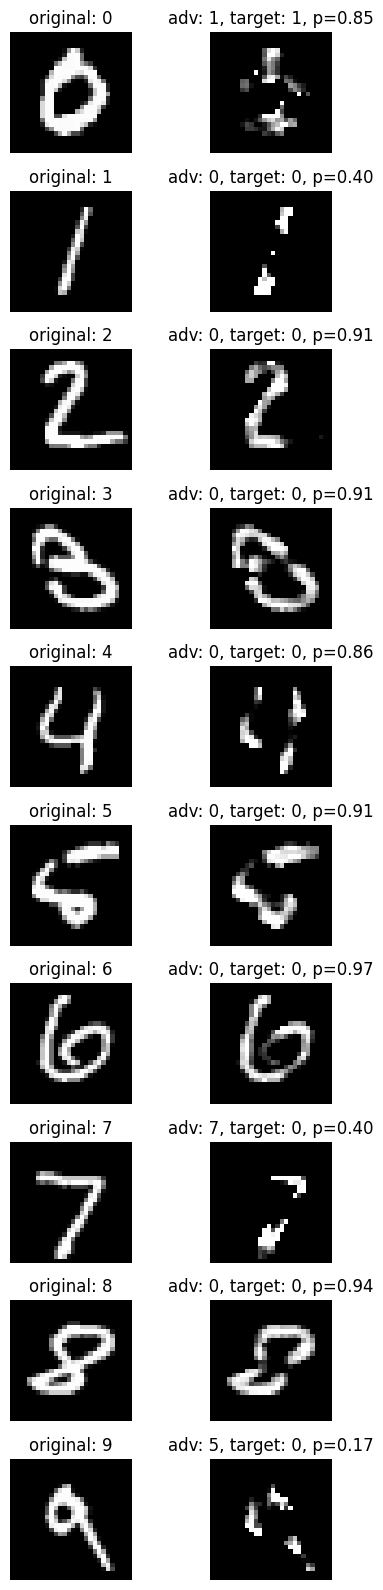

In [17]:
adv_images = adv_results[best_lambda]["adv_images"]
adv_preds = adv_results[best_lambda]["preds"]
target_probs = adv_results[best_lambda]["target_probs"]

indices = []
seen = {label: 0 for label in range(10)}

for i, label in enumerate(real_labels.detach().cpu().numpy()):
    if seen[label] == 0:
        indices.append(i)
        seen[label] += 1
    if len(indices) == 10:
        break

fig, axes = plt.subplots(10, 2, figsize=(4.8, 16))

for row, idx in enumerate(indices):
    original = denormalize(real_images[idx]).detach().cpu().squeeze().clamp(0, 1)
    adversarial = denormalize(adv_images[idx]).detach().cpu().squeeze().clamp(0, 1)
    true_label = real_labels[idx].item()
    target_label = wrong_labels[idx].item()
    pred_label = adv_preds[idx].item()
    conf = target_probs[idx].item()

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"original: {true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(adversarial, cmap="gray")
    axes[row, 1].set_title(f"adv: {pred_label}, target: {target_label}, p={conf:.2f}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

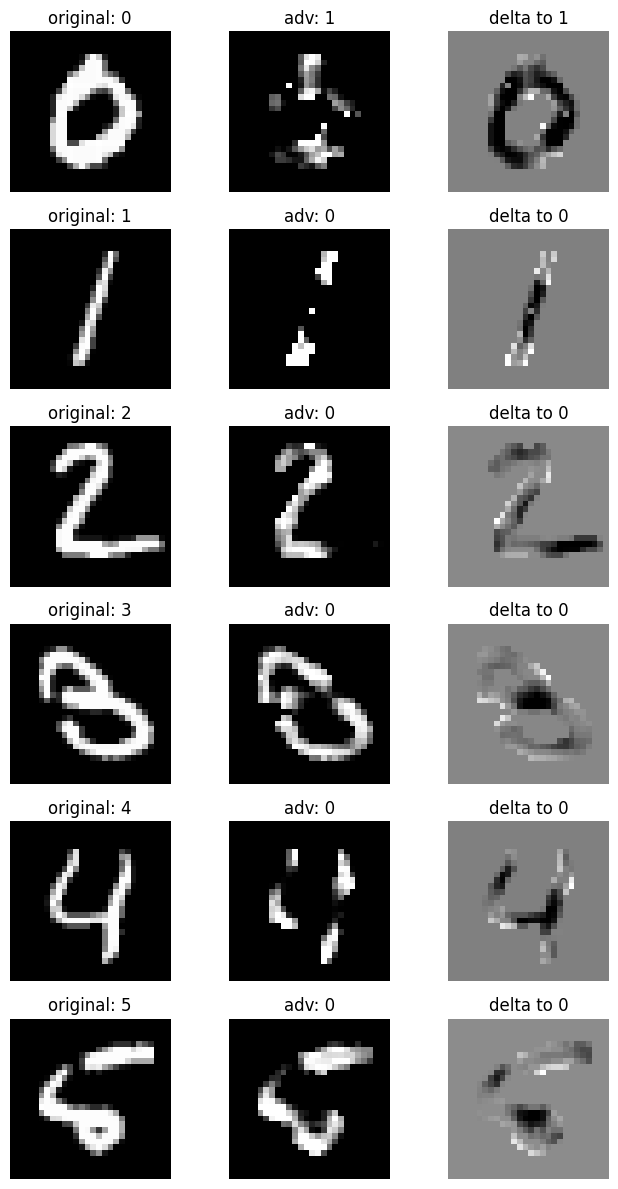

In [18]:
delta = adv_results[best_lambda]["delta"]
sample_indices = indices[:6]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(7, 12))

for row, idx in enumerate(sample_indices):
    original = denormalize(real_images[idx]).detach().cpu().squeeze().clamp(0, 1)
    adversarial = denormalize(adv_images[idx]).detach().cpu().squeeze().clamp(0, 1)
    perturbation = delta[idx].detach().cpu().squeeze()
    true_label = real_labels[idx].item()
    target_label = wrong_labels[idx].item()
    pred_label = adv_preds[idx].item()

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"original: {true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(adversarial, cmap="gray")
    axes[row, 1].set_title(f"adv: {pred_label}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(perturbation, cmap="gray")
    axes[row, 2].set_title(f"delta to {target_label}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

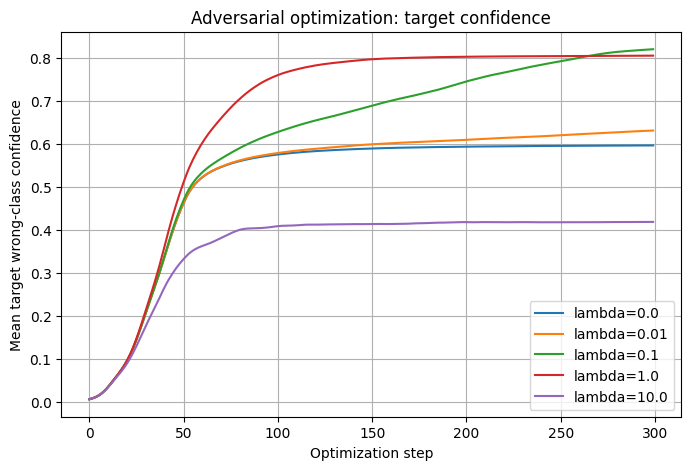

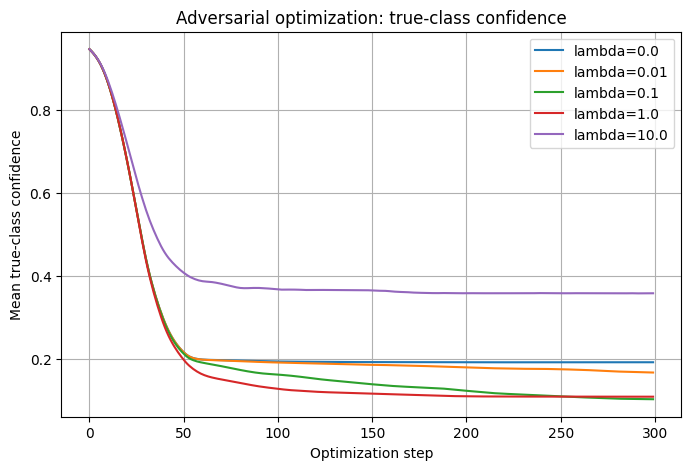

In [19]:
plt.figure(figsize=(8, 5))

for lambda_l2 in adv_lambdas:
    mean_target_conf = adv_results[lambda_l2]["target_conf_history"].mean(axis=1)
    plt.plot(mean_target_conf, label=f"lambda={lambda_l2}")

plt.xlabel("Optimization step")
plt.ylabel("Mean target wrong-class confidence")
plt.title("Adversarial optimization: target confidence")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

for lambda_l2 in adv_lambdas:
    mean_true_conf = adv_results[lambda_l2]["true_conf_history"].mean(axis=1)
    plt.plot(mean_true_conf, label=f"lambda={lambda_l2}")

plt.xlabel("Optimization step")
plt.ylabel("Mean true-class confidence")
plt.title("Adversarial optimization: true-class confidence")
plt.legend()
plt.grid(True)
plt.show()

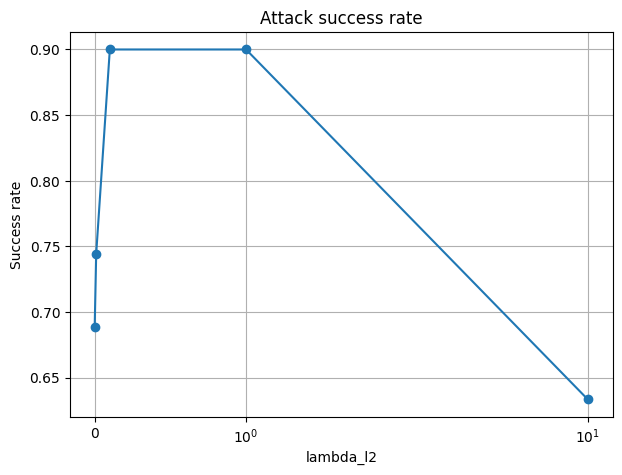

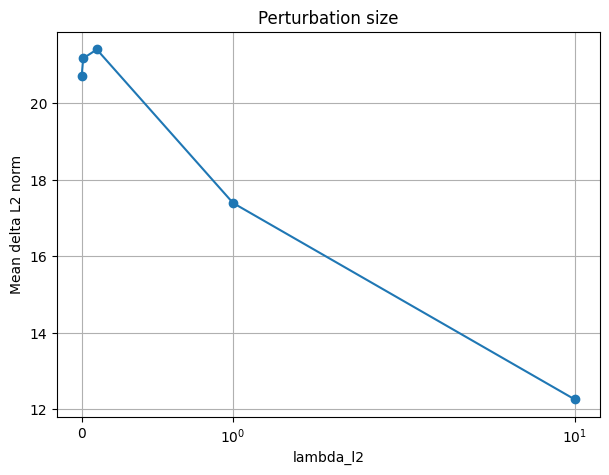

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(adv_summary["lambda_l2"], adv_summary["success_rate"], marker="o")
plt.xscale("symlog")
plt.xlabel("lambda_l2")
plt.ylabel("Success rate")
plt.title("Attack success rate")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(adv_summary["lambda_l2"], adv_summary["mean_delta_l2"], marker="o")
plt.xscale("symlog")
plt.xlabel("lambda_l2")
plt.ylabel("Mean delta L2 norm")
plt.title("Perturbation size")
plt.grid(True)
plt.show()

### Task 2 — odpowiedzi

Wartości liczbowe są w tabeli `adv_summary`.

Każda cyfra ma 9 ataków, po jednym na każdą inną klasę. Potwierdza to tabela `attack_plan`: na przekątnej są zera, poza przekątną jedynki.

Success rate wyniósł: `0.688889` dla $\lambda_{l2}=0$, `0.744444` dla `0.01`, `0.900000` dla `0.1`, `0.900000` dla `1.0` i `0.633333` dla `10.0`. Najlepszą skuteczność miały `0.1` i `1.0`.

Średnia norma perturbacji L2 wyniosła: `20.707508`, `21.169277`, `21.400133`, `17.390020`, `12.258387`. Nie maleje monotonicznie dla małych wartości $\lambda_{l2}$, ale przy większej karze, szczególnie od `0.1` do `10.0`, perturbacja wyraźnie maleje.

Średnia pewność klasy docelowej wyniosła: `0.596201`, `0.630752`, `0.819557`, `0.804612`, `0.418622`. Zbyt duża kara L2 osłabia atak.

Najlepszy kompromis w tych wynikach to $\lambda_{l2}=1.0$: success rate jest taki sam jak dla `0.1`, czyli `0.900000`, ale średnia norma perturbacji jest mniejsza (`17.390020` zamiast `21.400133`).

## Podsumowanie

LeNet-5 osiągnął `test_accuracy = 0.9558`, ale nadal jest podatny na optymalizację wejścia.

W Task 1 losowy szum można zmienić w obraz klasyfikowany z dużą pewnością jako zadana cyfra. Dla każdej wartości $\lambda_{l2}$ uzyskano `10/10` trafień klas docelowych. L2 zmniejsza amplitudę obrazu, ale nie gwarantuje realistycznych cyfr.

W Task 2 celowane perturbacje często zmieniają decyzję modelu na błędną klasę. Najlepszy success rate wyniósł `0.900000` dla $\lambda_{l2}=0.1$ i `1.0`. Najlepszy kompromis to $\lambda_{l2}=1.0$, bo zachowuje `0.900000` success rate przy mniejszej normie perturbacji.

Główny wniosek: CNN ma użyteczny bias lokalny, ale jego lokalne cechy można wykorzystać przeciwko niemu przez specjalnie dobrane zmiany pikseli.